## Import packages

In [105]:
import pandas as pd
import gzip
import re
import numpy as np
#from sklearn.decomposition import PCA
from pathlib import Path
from matplotlib import pyplot as plt
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
import gseapy as gp
from gseapy import barplot, dotplot, read_gmt
from adjustText import adjust_text
import rushd as rd

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
from textwrap import wrap

import warnings
warnings.filterwarnings("ignore",category=UserWarning)
warnings.filterwarnings("ignore",category=FutureWarning)

In [106]:
output_path =  rd.rootdir/'output'/'Figure_S14_rnaseq'


## Make tx2gene maps

In [107]:
# Make tsv for converting transcript_id.version to gene_id.version
# Only need to run this block once to make the file

# gtf_path = "data/genomes/GRCm39/Mus_musculus.GRCm39.114.chr.gtf.gz"
gtf_path = "C:/Users/Grad2024/Nextcloud/data/NGS/processed/2025.12.16_DASIT-iMN-RNAseq/data/genomes/GRCm39/Mus_musculus.GRCm39.115.chr.gtf.gz"

tx2gene_records = []
gene_name_map = {}

with gzip.open(gtf_path, 'rt') as f:
    for line in f:
        if line.startswith("#"): # skip the header lines
            continue
        parts = line.strip().split('\t')
        if len(parts) < 9: # ensure parts array is complete (expect length of 9)
            continue

        feature_type = parts[2] # gene, transcript, or exon
        attr_field = parts[8] # has info about gene_id, gene_version, gene_name, gene_source, and gene_biotype

        # Extract attributes using regex
        attrs = dict(re.findall(r'(\S+)\s+"([^"]+)"', attr_field))

        if feature_type == "transcript":
            transcript_id = attrs.get("transcript_id")
            gene_id = attrs.get("gene_id")

            transcript_version = attrs.get("transcript_version", "")
            gene_version = attrs.get("gene_version", "")

            if transcript_id and gene_id:
                tx_id_ver = f"{transcript_id}.{transcript_version}" if transcript_version else transcript_id
                gene_id_ver = f"{gene_id}.{gene_version}" if gene_version else gene_id
                tx2gene_records.append((tx_id_ver, gene_id_ver))

        if feature_type == "gene":
            gene_id = attrs.get("gene_id")
            gene_version = attrs.get("gene_version", "")
            gene_name = attrs.get("gene_name")

            if gene_id and gene_name:
                gene_id_ver = f"{gene_id}.{gene_version}" if gene_version else gene_id
                gene_name_map[gene_id_ver] = gene_name

# Save tx2gene
tx2gene_df = pd.DataFrame(tx2gene_records, columns=["transcript_id", "gene_id"])
tx2gene_df.to_csv("C:/Users/Grad2024/Nextcloud/data/NGS/processed/2025.12.16_DASIT-iMN-RNAseq/data/genomes/GRCm39/GRCm39_tx2gene.tsv", sep="\t", index=False)

# Save gene_id → gene_name map
gene_name_df = pd.DataFrame(list(gene_name_map.items()), columns=["gene_id", "gene_name"])
gene_name_df.to_csv("C:/Users/Grad2024/Nextcloud/data/NGS/processed/2025.12.16_DASIT-iMN-RNAseq/data/genomes/GRCm39/GRCm39_gene_id_to_name.tsv", sep="\t", index=False)

## Load data

In [108]:
# Read sample sheet
samplesheet = pd.read_csv("../config/samplesheet-full_deseq2.csv")
samplesheet = samplesheet[
    samplesheet["condition"].str.contains("FACS|DASIT50", case=False, na=False)
].copy()

# Split the "condition" column into other metadata
# e.g. condition = Puro-4dpi_rep1
# condition = Puro-4dpi, batch = 1, cond = Puro, dpi = 4
for index, row in samplesheet.iterrows():

    match = re.search(r'(?P<cond>.+)-(?P<dpi>\d+)dpi_rep(?P<rep>\d+)', row['condition'])

    # Map to quant.sf path
    # e.g.../data/salmon_quantification/Puro-4dpi_rep1_GRCm39/quant.sf
    quant_dir = Path("C:/Users/Grad2024/Nextcloud/data/NGS/processed/2025.12.16_DASIT-iMN-RNAseq/data/salmon_quantification")
    quant_path = quant_dir /  '{}_{}'.format(row['condition'], row['genome']) / 'quant.sf'
    samplesheet.loc[index, 'quant_path'] = quant_path

    # Save original condition as sample_name
    samplesheet.loc[index, 'sample_name'] = row['condition']
    # Replace condition without rep information
    samplesheet.loc[index, 'condition'] = match.group('cond') + "-" +  match.group('dpi')

    # Add in other meta data
    samplesheet.loc[index, 'cond'] = match.group('cond')
    samplesheet.loc[index, 'batch'] = match.group('rep')
    samplesheet.loc[index, 'dpi'] = match.group('dpi')

    

samplesheet = samplesheet.set_index("sample_name")

samplesheet

,condition,genome,shortCond,quant_path,cond,batch,dpi
sample_name,,,,,,,
LNI-SDDIR-FACS-14dpi_rep1,LNI-SDDIR-FACS-14,GRCm39,FACS,C:\Users\Grad2024\Nextcloud\data\NGS\processed...,LNI-SDDIR-FACS,1,14
LNI-SDDIR-FACS-14dpi_rep2,LNI-SDDIR-FACS-14,GRCm39,FACS,C:\Users\Grad2024\Nextcloud\data\NGS\processed...,LNI-SDDIR-FACS,2,14
LNI-SDDIR-FACS-14dpi_rep3,LNI-SDDIR-FACS-14,GRCm39,FACS,C:\Users\Grad2024\Nextcloud\data\NGS\processed...,LNI-SDDIR-FACS,3,14
LNI-SDDIR-DASIT50-14dpi_rep1,LNI-SDDIR-DASIT50-14,GRCm39,DASIT,C:\Users\Grad2024\Nextcloud\data\NGS\processed...,LNI-SDDIR-DASIT50,1,14
LNI-SDDIR-DASIT50-14dpi_rep2,LNI-SDDIR-DASIT50-14,GRCm39,DASIT,C:\Users\Grad2024\Nextcloud\data\NGS\processed...,LNI-SDDIR-DASIT50,2,14
LNI-SDDIR-DASIT50-14dpi_rep3,LNI-SDDIR-DASIT50-14,GRCm39,DASIT,C:\Users\Grad2024\Nextcloud\data\NGS\processed...,LNI-SDDIR-DASIT50,3,14
LNI-SDDIR-FACS-21dpi_rep1,LNI-SDDIR-FACS-21,GRCm39,FACS,C:\Users\Grad2024\Nextcloud\data\NGS\processed...,LNI-SDDIR-FACS,1,21
LNI-SDDIR-FACS-21dpi_rep2,LNI-SDDIR-FACS-21,GRCm39,FACS,C:\Users\Grad2024\Nextcloud\data\NGS\processed...,LNI-SDDIR-FACS,2,21
LNI-SDDIR-FACS-21dpi_rep3,LNI-SDDIR-FACS-21,GRCm39,FACS,C:\Users\Grad2024\Nextcloud\data\NGS\processed...,LNI-SDDIR-FACS,3,21


In [109]:
# Read tx2gene mapping
tx2gene = pd.read_csv("C:/Users/Grad2024/Nextcloud/data/NGS/processed/2025.12.16_DASIT-iMN-RNAseq/data/genomes/GRCm39/GRCm39_tx2gene.tsv", sep="\t")
tx2gene_dict = dict(zip(tx2gene["transcript_id"], tx2gene["gene_id"]))

# Also read in gene_id_to_name map
gene_id_to_name = pd.read_csv("C:/Users/Grad2024/Nextcloud/data/NGS/processed/2025.12.16_DASIT-iMN-RNAseq/data/genomes/GRCm39/GRCm39_gene_id_to_name.tsv", sep="\t")
gene_to_name_dict = dict(zip(gene_id_to_name["gene_id"], gene_id_to_name["gene_name"]))

# make metadata df from samplesheet
metadata = samplesheet[['condition','batch']]

In [110]:
# Build gene-level count matrix from quant.sf files
def read_salmon_counts(quant_path, tx2gene):
    df = pd.read_csv(quant_path, sep="\t", engine="python")
    df = df[df["Name"].isin(tx2gene)]
    df["gene_id"] = df["Name"].map(tx2gene)
    return df.groupby("gene_id")["NumReads"].sum()

# Generate count matrix
counts_dfs_dict = {  sample: read_salmon_counts(row["quant_path"], tx2gene_dict) for sample, row in samplesheet.iterrows()  } # dictionary of sample:counts_matrix
counts_df = pd.DataFrame(counts_dfs_dict).fillna(0).astype(int) # create dataframe, the keys (samples) become columns and the values (NumReads) become the column data

display(counts_df.shape)

# Remove genes that are very lowly expressed (<10 total reads across all samples) to pre-filter genes
counts_df = counts_df[counts_df.sum(axis=1) > 10]
# Transpose to match dimensions later on
counts_df = counts_df.T

display(counts_df.shape)

csv_title = 'counts_FACS_DASIT.csv'
counts_df.to_csv(output_path/csv_title, index=True)



(35588, 12)

(12, 17924)

## Run DESeq2

control_genes : ndarray, list, or pandas.Index, optional

Genes to use as control genes for size factor fitting. If provided, size factors will be fit using only these genes. This is useful when certain genes are known to be invariant across conditions (e.g., housekeeping genes). Any valid AnnData indexer (bool array, integer positions, or gene name strings) can be used. (default: ``None``).

In [111]:
counts_14 = counts_df[
    counts_df.index.str.contains("14dpi")
].copy()
metadata_14 = metadata[
    metadata.index.str.contains("14dpi")
].copy()
counts_14 = counts_14.loc[metadata_14.index]
counts_14

gene_id,ENSMUSG00000000001.5,ENSMUSG00000000028.16,ENSMUSG00000000037.18,ENSMUSG00000000049.12,ENSMUSG00000000056.8,ENSMUSG00000000058.7,ENSMUSG00000000078.8,ENSMUSG00000000085.17,ENSMUSG00000000088.8,ENSMUSG00000000093.7,...,ENSMUSG00000141871.2,ENSMUSG00000144222.1,ENSMUSG00000144223.1,ENSMUSG00000144226.1,ENSMUSG00000144232.1,ENSMUSG00000144250.1,ENSMUSG00000144260.1,ENSMUSG00000144276.1,ENSMUSG00000144291.1,ENSMUSG00002076083.1
sample_name,,,,,,,,,,,,,,,,,,,,,
LNI-SDDIR-FACS-14dpi_rep1,3645,218,4,0,495,1425,2854,377,9574,288,...,0,9,677,6,4,23,11,7,171,19
LNI-SDDIR-FACS-14dpi_rep2,3981,226,12,0,459,1374,3115,431,8701,350,...,0,23,651,1,1,30,20,3,174,22
LNI-SDDIR-FACS-14dpi_rep3,4043,246,7,0,550,1446,3137,537,9556,590,...,0,22,704,0,5,36,27,0,243,20
LNI-SDDIR-DASIT50-14dpi_rep1,3926,242,7,5,587,2336,3343,597,11329,96,...,0,14,717,1,3,94,6,3,204,23
LNI-SDDIR-DASIT50-14dpi_rep2,3302,275,5,2,465,2072,3016,388,11170,122,...,0,12,628,3,0,76,4,3,220,23
LNI-SDDIR-DASIT50-14dpi_rep3,3779,249,5,0,505,2433,3458,609,11810,220,...,0,8,623,0,1,61,15,1,231,27


In [112]:
counts_21 = counts_df[
    counts_df.index.str.contains("21dpi")
].copy()
metadata_21 = metadata[
    metadata.index.str.contains("21dpi")
].copy()
counts_21 = counts_21.loc[metadata_21.index]
counts_21

gene_id,ENSMUSG00000000001.5,ENSMUSG00000000028.16,ENSMUSG00000000037.18,ENSMUSG00000000049.12,ENSMUSG00000000056.8,ENSMUSG00000000058.7,ENSMUSG00000000078.8,ENSMUSG00000000085.17,ENSMUSG00000000088.8,ENSMUSG00000000093.7,...,ENSMUSG00000141871.2,ENSMUSG00000144222.1,ENSMUSG00000144223.1,ENSMUSG00000144226.1,ENSMUSG00000144232.1,ENSMUSG00000144250.1,ENSMUSG00000144260.1,ENSMUSG00000144276.1,ENSMUSG00000144291.1,ENSMUSG00002076083.1
sample_name,,,,,,,,,,,,,,,,,,,,,
LNI-SDDIR-FACS-21dpi_rep1,1582,230,8,2,291,987,1549,427,6416,1513,...,3,19,619,4,0,30,18,1,206,20
LNI-SDDIR-FACS-21dpi_rep2,1898,272,7,1,264,796,1785,308,6880,1132,...,11,17,533,0,0,34,29,0,202,35
LNI-SDDIR-FACS-21dpi_rep3,2163,315,11,2,249,677,1918,350,7685,1051,...,1,16,486,0,1,16,36,2,207,7
LNI-SDDIR-DASIT50-21dpi_rep1,253,32,1,0,54,223,260,94,1515,27,...,0,13,53,0,0,16,8,0,24,1
LNI-SDDIR-DASIT50-21dpi_rep2,345,25,3,0,61,234,360,124,1794,55,...,0,5,102,0,0,9,12,0,27,11
LNI-SDDIR-DASIT50-21dpi_rep3,673,65,3,0,161,578,714,351,3637,227,...,0,14,202,0,0,21,14,0,84,20


In [113]:
dds_14 = DeseqDataSet(
    counts=counts_14,
    metadata=metadata_14,
    design="~ condition"
)

dds_21 = DeseqDataSet(
    counts=counts_21,
    metadata=metadata_21,
    design="~ condition"
)

In [114]:
dds_14.deseq2()
dds_21.deseq2()

Fitting size factors...
... done in 0.01 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 4.42 seconds.

Fitting dispersion trend curve...
... done in 0.99 seconds.

Fitting MAP dispersions...
... done in 4.28 seconds.

Fitting LFCs...
... done in 2.93 seconds.

Calculating cook's distance...
... done in 0.04 seconds.

Replacing 0 outlier genes.

Fitting size factors...
... done in 0.01 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 3.75 seconds.

Fitting dispersion trend curve...
... done in 0.76 seconds.

Fitting MAP dispersions...
... done in 4.35 seconds.

Fitting LFCs...
... done in 3.54 seconds.

Calculating cook's distance...
... done in 0.04 seconds.

Replacing 0 outlier genes.



In [115]:
ds_14 = DeseqStats(dds_14, contrast=["condition", "LNI-SDDIR-DASIT50-14", "LNI-SDDIR-FACS-14"])
#  Run the Wald tests, with default Cook's distance filtering and independent filtering
ds_14.summary()
 
# A tidy results table lives here:
ds_res_14 = ds_14.results_df  # columns include: baseMean, log2FoldChange, lfcSE, stat, pvalue, padj
ds_res_sig_14 = ds_res_14.query("padj < 0.05").sort_values("padj")
ds_res_sig_14["symbol"] = ds_res_sig_14.index.map(gene_to_name_dict)
ds_res_sig_14.head()

#slightly different definition for GSEA
# # rename Ensembl ID to the gene symbol
ds_res_14['symbol'] = ds_res_14.index.map(gene_to_name_dict)

nan_count = ds_res_14['symbol'].isna().sum() # for some reason there are 57 gene_ids that didn't get mapped

# For pre-ranked GSEA, sort values by stat and drop duplicate gene symbols
ranking_14 = ds_res_14[['symbol','stat']].dropna().sort_values('stat',ascending=False)
ranking_14 = ranking_14.drop_duplicates('symbol')



Running Wald tests...
... done in 2.13 seconds.



Log2 fold change & Wald test p-value: condition LNI-SDDIR-DASIT50-14 vs LNI-SDDIR-FACS-14
                          baseMean  log2FoldChange     lfcSE      stat  \
gene_id                                                                  
ENSMUSG00000000001.5   3764.030834       -0.087260  0.078934 -1.105487   
ENSMUSG00000000028.16   242.307631        0.155569  0.162925  0.954849   
ENSMUSG00000000037.18     6.655145       -0.443157  0.872286 -0.508041   
ENSMUSG00000000049.12     1.161620        3.662848  2.915021  1.256543   
ENSMUSG00000000056.8    507.676684        0.049107  0.124107  0.395683   
...                            ...             ...       ...       ...   
ENSMUSG00000144250.1     53.153738        1.381222  0.337710  4.089961   
ENSMUSG00000144260.1     13.636424       -1.220654  0.672450 -1.815233   
ENSMUSG00000144276.1      2.879905       -0.531515  1.420202 -0.374253   
ENSMUSG00000144291.1    206.178682        0.162728  0.180844  0.899824   
ENSMUSG00002076083.1  

In [116]:
ds_21 = DeseqStats(dds_21, contrast=["condition", "LNI-SDDIR-DASIT50-21", "LNI-SDDIR-FACS-21"])
#  Run the Wald tests, with default Cook's distance filtering and independent filtering
ds_21.summary()
 
# A tidy results table lives here:
ds_res_21 = ds_21.results_df  # columns include: baseMean, log2FoldChange, lfcSE, stat, pvalue, padj
ds_res_sig_21 = ds_res_21.query("padj < 0.05").sort_values("padj")
ds_res_sig_21["symbol"] = ds_res_sig_21.index.map(gene_to_name_dict)
ds_res_sig_21.head()

#slightly different definition for GSEA
# rename Ensembl ID to the gene symbol
ds_res_21['symbol'] = ds_res_21.index.map(gene_to_name_dict)

nan_count = ds_res_21['symbol'].isna().sum() # for some reason there are 57 gene_ids that didn't get mapped

# For pre-ranked GSEA, sort values by stat and drop duplicate gene symbols
ranking_21 = ds_res_21[['symbol','stat']].dropna().sort_values('stat',ascending=False)
ranking_21 = ranking_21.drop_duplicates('symbol')

Running Wald tests...
... done in 2.24 seconds.



Log2 fold change & Wald test p-value: condition LNI-SDDIR-DASIT50-21 vs LNI-SDDIR-FACS-21
                         baseMean  log2FoldChange     lfcSE      stat  \
gene_id                                                                 
ENSMUSG00000000001.5   861.281212       -0.412572  0.156709 -2.632723   
ENSMUSG00000000028.16  107.163673       -1.005630  0.266106 -3.779052   
ENSMUSG00000000037.18    4.425635       -0.106660  1.022559 -0.104307   
ENSMUSG00000000049.12    0.435558       -1.319217  3.433753 -0.384191   
ENSMUSG00000000056.8   147.213787        0.138491  0.212457  0.651852   
...                           ...             ...       ...       ...   
ENSMUSG00000144250.1    21.721446        1.018211  0.542927  1.875410   
ENSMUSG00000144260.1    18.101791        0.544188  0.552700  0.984600   
ENSMUSG00000144276.1     0.258042       -0.565607  4.297884 -0.131601   
ENSMUSG00000144291.1    89.938214       -0.534523  0.260087 -2.055173   
ENSMUSG00002076083.1    13.664098 

# Initial plots

## Plotting functions

Figure 14C log2FC

In [117]:
sns.set_theme(style="ticks",font_scale=1)

def plot_volcano(res,
    log2fc_thresh=1,
    pval_thresh=0.05,
    n_labels=10,
    figsize=(5, 5),
    title='',
    xlim=[-10,10]):
    """
    Create a volcano plot directly from a PyDESeq2 DeseqStats dataframe.

    Parameters:
    - res: DeseqDataSet dataframe (from PyDESeq2 and then DeseqStats) with gene symbols added
    - gene_names: list or Series of gene symbols (must match dds results index order)
    - log2fc_thresh: threshold for log2 fold change
    - pval_thresh: threshold for adjusted p-value
    - n_labels: number of top significant genes to label
    - figsize: figure size
    - colors: (non-significant, significant) point colors
    - title: plot title
    """
    # Extract DE results
    df = res.copy()

    # Ensure necessary columns are present
    required_cols = {'log2FoldChange', 'padj','symbol'}
    if not required_cols.issubset(df.columns):
        raise ValueError("dds.results_df must contain 'log2FoldChange', 'padj', and columns")

    # Drop NA values
    df = df.dropna(subset=['log2FoldChange', 'padj'])

    # Compute -log10 adjusted p-value
    df['-log10(padj)'] = -np.log10(df['padj'])

    # Determine significance
    df['significant'] = (df['padj'] < pval_thresh) & (abs(df['log2FoldChange']) > log2fc_thresh)
    conditions = [(df['padj'] < pval_thresh) & (df['log2FoldChange'] > log2fc_thresh),
                  (df['padj'] < pval_thresh) & (df['log2FoldChange'] < -log2fc_thresh)]
    choices = ['up', 'down']
    df['regulation'] = np.select(conditions, choices, default='ns')

    # Start plot
    plt.figure(figsize=figsize)
    ax = sns.scatterplot(data=df,
                    x='log2FoldChange',
                    y='-log10(padj)',
                    hue='regulation',
                    palette={'ns': "#cecece", 'up': '#ee9e9e', 'down': '#7491b6'},
                    edgecolor=None,
                    linewidth=0,
                    alpha=0.8,
                    legend=True)

    # Add threshold lines
    plt.axhline(-np.log10(pval_thresh), color='black', linestyle='--', lw=1)
    plt.axvline(-log2fc_thresh, color='black', linestyle='--', lw=1)
    plt.axvline(log2fc_thresh, color='black', linestyle='--', lw=1)

    # Move legend
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1.05, 1),frameon=False)

    # Change xlim
    ax.set_xlim(left=xlim[0],right=xlim[1])

    # Annotate top genes
    top_genes = df[df['significant']].sort_values('padj').head(n_labels)
    top_fold_genes =  df[df['significant']].sort_values('log2FoldChange').head(n_labels)
    top_handpicked_genes = df[df['symbol'].isin(['Vgll2', 'Ccl11', 'Tff3', 'Notch1', 'Csn3', 'Lum', 'Tead2', 'Id3', 'Col3a', 'Fbn2', 'Id1', 'Dcn'])]  # replace with actual gene symbols of interest
    texts = [plt.text(row['log2FoldChange'], row['-log10(padj)'], row['symbol'], fontsize=9)
             for _, row in top_handpicked_genes.iterrows()]
    adjust_text(texts, arrowprops=dict(arrowstyle='-', color='black', lw=0.5))

    plt.xlabel('log2(Fold Change)', fontsize=17)
    plt.ylabel('-log10(adjusted p-value)', fontsize=17)
    plt.title(title, fontsize=17)
    plt.tight_layout()
    plottitle = 'Figure_S14_log_fc.png'
    plt.savefig(rd.outfile(output_path/plottitle),dpi=600,bbox_inches='tight')
    plt.show()

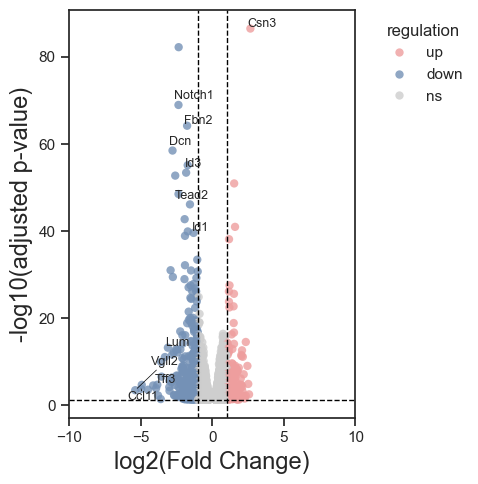

In [118]:
plot_volcano(ds_res_sig_14, n_labels=10)

Figure 14A correlation

Pooled correlation: 0.9844451175071864
Pooled correlation: 0.9844451175071864


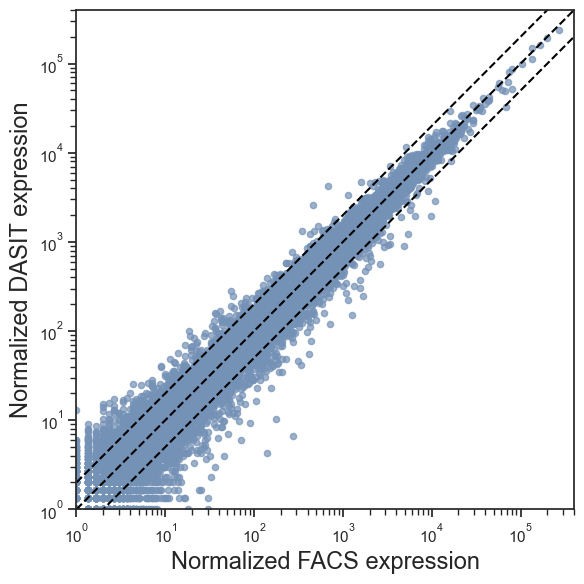

,FACS,DASIT,log2FC
symbol,,,
Gm15387,45.000000,0.000000,5.523562
Gvin2,39.333333,0.000000,5.333901
Gm10154,35.333333,0.000000,5.183222
Vgll2,277.333333,6.666667,5.182070
Ccl11,139.333333,4.333333,4.717676
Btf3l4b,19.666667,0.000000,4.369234
Pdf,0.000000,18.666667,-4.297681
Tff3,178.333333,10.333333,3.984000
Kera,30.000000,1.000000,3.954196


In [128]:
norm_counts_14 = dds_14.to_df()

norm_counts_14 = norm_counts_14.T
norm_counts_14.index = norm_counts_14.index.str.split(".").str[0]
norm_counts_14['gene_id'] = norm_counts_14.index
norm_counts_14['symbol'] = norm_counts_14.index.map(gene_to_name_dict_no_version)
norm_counts_14 = norm_counts_14.set_index("symbol")
norm_counts_14 = norm_counts_14[["gene_id"] + [c for c in norm_counts_14.columns if c != "gene_id"]]
csv_title = '14dpi_normalized_counts_FACS_DASIT.csv'
norm_counts_14.to_csv(output_path/csv_title, index=True)

#norm_counts_14.index = norm_counts_14.index.map(lambda x: gene_to_name_dict_no_version.get(x, x))

facs_cols  = [c for c in norm_counts_14.columns if "LNI-SDDIR-FACS-14dpi" in c]
dasit_cols = [c for c in norm_counts_14.columns if "LNI-SDDIR-DASIT50-14dpi" in c]
facs_vals  = norm_counts_14[facs_cols].values.flatten()
dasit_vals = norm_counts_14[dasit_cols].values.flatten()



r = pd.Series(facs_vals).corr(pd.Series(dasit_vals), method="pearson")
print("Pooled correlation:", r)

r = pd.Series(facs_vals).corr(pd.Series(dasit_vals), method="pearson")
print("Pooled correlation:", r)

facs_mean  = norm_counts_14[facs_cols].mean(axis=1)
dasit_mean = norm_counts_14[dasit_cols].mean(axis=1)

facs_mean = facs_mean.groupby(facs_mean.index).mean()
dasit_mean = dasit_mean.groupby(dasit_mean.index).mean()

plot_df = (
    pd.DataFrame({
        "FACS": facs_mean,
        "DASIT": dasit_mean
    })
    .dropna()
)

plot_df = plot_df.groupby(plot_df.index).mean()

# log2 fold change used only to pick outliers
plot_df["log2FC"] = np.log2((plot_df["FACS"] + 1) / (plot_df["DASIT"] + 1))

top_genes = plot_df["log2FC"].abs().nlargest(10).index

fig, ax = plt.subplots(figsize=(6,6))

scatter = ax.scatter(plot_df["FACS"], plot_df["DASIT"], color = '#7491b6', s=20, alpha=0.7)

ax.set_xscale("log")
ax.set_yscale("log")

texts = []
points_x = []
points_y = []


x = np.linspace(1, 800000, 500)
y1 = (x)
y2 = 2*x
y3 = 0.5*x

ax.plot(x, y1, color="black", linestyle='--', label='y = x')
ax.plot(x, y2, color="black", linestyle='--', label='y = 2x')
ax.plot(x, y3, color="black", linestyle='--', label='y = 0.5x')

ax.set_xlabel("Normalized FACS expression", fontsize=17)
ax.set_ylabel("Normalized DASIT expression", fontsize=17)
ax.set_xlim(1, 400000)
ax.set_ylim(1, 400000)
#plt.title(f"FACS vs DASIT (r = {r:.3f})")


plt.tight_layout()
plottitle = 'Figure_S14_correlation.png'
plt.savefig(rd.outfile(output_path/plottitle),dpi=600,bbox_inches='tight')
plt.show()
    
plot_df.loc[top_genes]


Figure 14D heat map

Pooled correlation: 0.8237188030040975


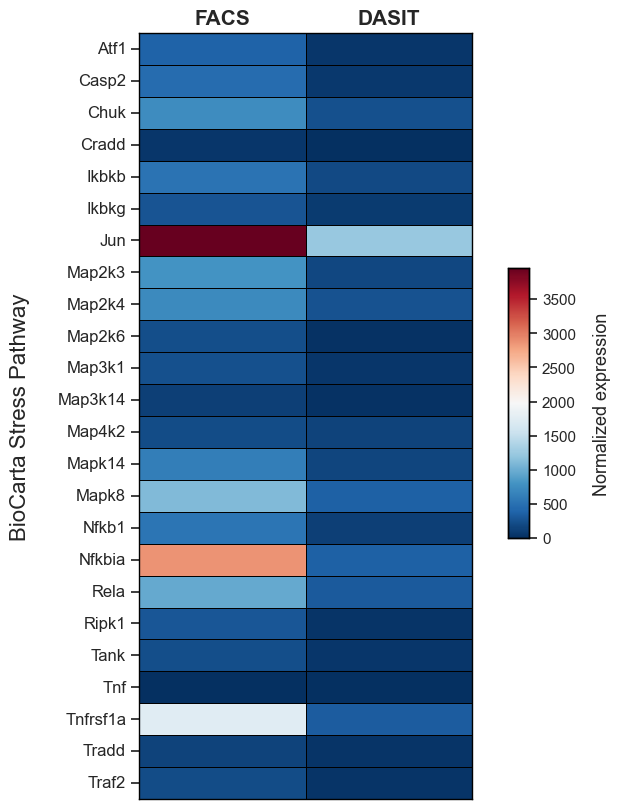

In [127]:
# 21 dpi BIOCARTA_STRESS_PATHWAY COMPARISON

# -----------------------------
# Get FACS and DASIT columns
# -----------------------------

norm_counts_21 = dds_21.to_df()

norm_counts_21 = norm_counts_21.T
norm_counts_21.index = norm_counts_21.index.str.split(".").str[0]
norm_counts_21['gene_id'] = norm_counts_21.index
norm_counts_21['symbol'] = norm_counts_21.index.map(gene_to_name_dict_no_version)
norm_counts_21 = norm_counts_21.set_index("symbol")
norm_counts_21 = norm_counts_21[["gene_id"] + [c for c in norm_counts_21.columns if c != "gene_id"]]
csv_title = '21dpi_normalized_counts_FACS_DASIT.csv'
norm_counts_21.to_csv(output_path/csv_title, index=True)

facs_cols_21  = [c for c in norm_counts_21.columns if "LNI-SDDIR-FACS-21dpi" in c]
dasit_cols_21 = [c for c in norm_counts_21.columns if "LNI-SDDIR-DASIT50-21dpi" in c]
facs_vals_21  = norm_counts_21[facs_cols_21].values.flatten()
dasit_vals_21 = norm_counts_21[dasit_cols_21].values.flatten()

r = pd.Series(facs_vals_21).corr(
    pd.Series(dasit_vals_21),
    method="pearson"
)

print("Pooled correlation:", r)


# -----------------------------
# Calculate mean expression
# -----------------------------

facs_mean21 = norm_counts_21[facs_cols_21].mean(axis=1)
dasit_mean21 = norm_counts_21[dasit_cols_21].mean(axis=1)

facs_mean21 = facs_mean21.groupby(facs_mean21.index).mean()
dasit_mean21 = dasit_mean21.groupby(dasit_mean21.index).mean()

plot_df_21 = (
    pd.DataFrame({
        "FACS": facs_mean21,
        "DASIT": dasit_mean21
    })
    .dropna()
)

plot_df_21 = plot_df_21.groupby(plot_df_21.index).mean()


# -----------------------------
# Genes of interest
# -----------------------------

goi = [
    'Tnfrsf1a',
    'Tradd',
    'Ikbkb',
    'Ikbkg',
    'Chuk',
    'Mapk14',
    'Atf1',
    'Casp2',
    'Nfkb1',
    'Map2k3',
    'Map4k2',
    'Rela',
    'Ripk1',
    'Map2k4',
    'Traf2',
    'Cradd',
    'Jun',
    'Nfkbia',
    'Tank',
    'Tnfrsf1a',
    'Map2k6',
    'Map3k1',
    'Tnf',
    'Mapk8',
    'Map3k14'
]

norm_counts_log_subset = plot_df_21.loc[
    plot_df_21.index.isin(goi)
].copy()

# Remove duplicate gene names
norm_counts_log_subset = norm_counts_log_subset[
    ~norm_counts_log_subset.index.duplicated(keep='first')
]


# -----------------------------
# Create clustermap
# -----------------------------

g = sns.clustermap(
    norm_counts_log_subset,
    cmap='RdBu_r',
    row_cluster=False,
    col_cluster=False,

    figsize=(6, 9),

    # No dendrograms
    dendrogram_ratio=(0.01, 0.01),

    # Leave room for colorbar
    cbar_pos=None,

    # Black borders around cells
    linewidths=0.5,
    linecolor='black',


    xticklabels=True,
    yticklabels=True,
    
    cbar_kws={
            'label': 'Normalized expression'}
)


ax = g.ax_heatmap


# ============================================================
# HEATMAP OUTLINE
# ============================================================

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)
    spine.set_edgecolor('black')


# ============================================================
# X-AXIS LABELS
# ============================================================

ax.set_xticklabels(
    ['FACS', 'DASIT'],
    fontsize=15,
    fontweight='bold'
)

ax.tick_params(
    axis='x',
    bottom=False,
    top=True,
    labelbottom=False,
    labeltop=True,
    length=0
)


# ============================================================
# Y-AXIS / GENE LABELS
# ============================================================

n_genes = len(norm_counts_log_subset)

# Explicitly put one tick at every heatmap row
ax.set_yticks(
    np.arange(n_genes) + 0.5
)

# Explicitly provide every gene name
ax.set_yticklabels(
    norm_counts_log_subset.index.tolist(),
    fontsize=12
)

ax.yaxis.tick_left()

ax.yaxis.set_label_position('left')


# Custom y-axis label
ax.set_ylabel(
    'BioCarta Stress Pathway',
    fontsize=16,
    labelpad=20
)


# # Make labels align toward the heatmap
# for label in ax.get_yticklabels():
#     label.set_horizontalalignment('right')




# ============================================================
# COLORBAR
# ============================================================

# Get the heatmap's colormap and normalization
mappable = ax.collections[0]

cbar = g.ax_cbar
# g.ax_cbar.set_position([
#     0.9,   # left
#     0.35,   # bottom
#     0.035,  # width
#     0.30    # height
# ])
# Explicitly put colorbar on RIGHT
cbar_ax = g.fig.add_axes(
    [0.9, 0.35, 0.035, 0.3]
)
cbar = g.fig.colorbar(
    mappable,
    cax=cbar_ax
)
cbar.set_label(
    'Normalized expression',
    fontsize=13,
    rotation=90,
    labelpad=12
)

cbar.ax.tick_params(
    labelsize=11
)

# Black outline
for spine in cbar.ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)
    spine.set_edgecolor('black')


# ============================================================
# COLUMN TITLE
# ============================================================

ax.set_title(
    '',
    pad=10
)


# ============================================================
# LAYOUT
# ============================================================

g.fig.subplots_adjust(
    left=0.28,     # room for gene names
    right=0.84,    # room for colorbar
    top=0.92,
    bottom=0.06
)


# # Colorbar immediately right of heatmap
# g.ax_cbar.set_position([
#     0.9,   # left
#     0.35,   # bottom
#     0.035,  # width
#     0.30    # height
# ])
# Make sure all labels are rendered
g.fig.canvas.draw()

plottitle = 'Figure_S14_heatmap.png'
plt.savefig(rd.outfile(output_path/plottitle),dpi=600,bbox_inches='tight')
plt.show()

In [121]:
#showing that the biocarta stress pathway is significantly downregulated in the DASIT samples at 21 dpi
gmt = read_gmt(r"C:\Users\Grad2024\Downloads\BIOCARTA_STRESS_PATHWAY.v2026.1.Mm.gmt")
print(list(gmt.keys())[:5])  
print(gmt["BIOCARTA_STRESS_PATHWAY"])
set = gmt

#21 dpi 
pre_res_21 = gp.prerank(rnk=ranking_21,gene_sets=set,seed=3,permutation_num=1000, threads=1)
pre_res_21.res2d.head()

2026-09-24 09:43:30,539 [WARNING] Duplicated values found in preranked stats: 2.86% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


['BIOCARTA_STRESS_PATHWAY']
['Atf1', 'Casp2', 'Chuk', 'Cradd', 'Ikbkb', 'Ikbkg', 'Jun', 'Map2k3', 'Map2k4', 'Map2k6', 'Map3k1', 'Map3k14', 'Map4k2', 'Mapk14', 'Mapk8', 'Nfkb1', 'Nfkbia', 'Rela', 'Ripk1', 'Tank', 'Tnf', 'Tnfrsf1a', 'Tradd', 'Traf2']


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,BIOCARTA_STRESS_PATHWAY,-0.51945,-1.443489,0.047154,0.047154,0.047154,15/24,28.94%,Nfkbia;Map2k6;Ripk1;Atf1;Casp2;Tnfrsf1a;Nfkb1;...


Figure S14B GSEA

In [122]:
# GSEA

# Run Gene Set Enrichment Analysis (GSEA) for chosen gene set library
#gp.get_library_name(organism='Mouse') # see options for gene libraries
set = 'MSigDB_Hallmark_2020'
pre_res_14 = gp.prerank(rnk=ranking_14,gene_sets=set,seed=6,permutation_num=1000)
print(pre_res_14.res2d.head())

2026-09-24 09:43:32,694 [WARNING] Duplicated values found in preranked stats: 0.78% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


      Name                               Term        ES       NES  NOM p-val  \
0  prerank          Oxidative Phosphorylation  0.643570  2.811497        0.0   
1  prerank  Epithelial Mesenchymal Transition -0.629993 -2.681797        0.0   
2  prerank                    G2-M Checkpoint -0.619761 -2.633248        0.0   
3  prerank                        E2F Targets -0.591275 -2.529269        0.0   
4  prerank                    Mitotic Spindle -0.534011 -2.271029        0.0   

   FDR q-val  FWER p-val    Tag %  Gene %  \
0        0.0         0.0   95/194  11.86%   
1        0.0         0.0   85/193  10.10%   
2        0.0         0.0  111/197  17.77%   
3        0.0         0.0  121/195  22.95%   
4        0.0         0.0   75/197  14.92%   

                                          Lead_genes  
0  Atp1b1;Cox8a;Atp6v0c;Cox6c;Ndufa1;Ndufa5;Mpc1;...  
1  Col3a1;Fbn2;Dcn;Col1a1;Igfbp4;Serpinh1;Pcolce;...  
2  Marcks;Ezh2;Lmnb1;Ube2c;Stmn1;Srsf1;Cdk4;H2az2...  
3  Hmgb2;Anp32e;Ezh2;Lmnb1;N

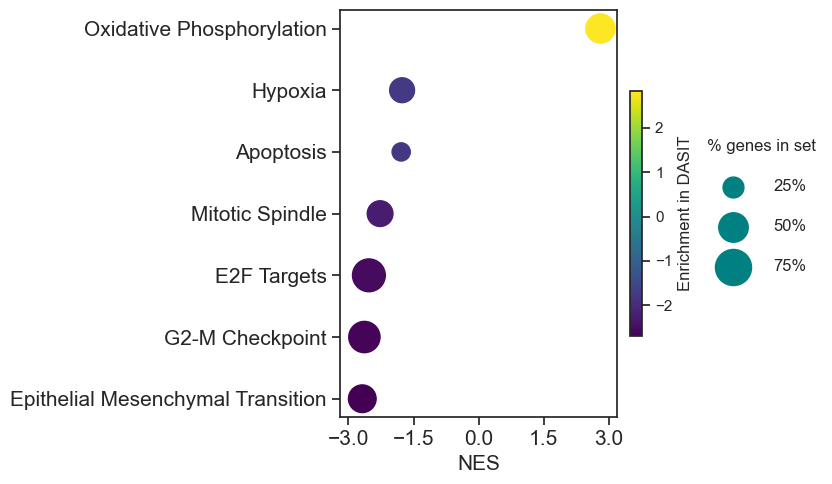

In [123]:
keep_terms = ['Oxidative Phosphorylation', 'Epithelial Mesenchymal Transition', 'G2-M Checkpoint', 'E2F Targets', 'Mitotic Spindle', 'Apoptosis', 'Hypoxia']
res = pre_res_14.res2d
res_subset = res[res["Term"].isin(keep_terms)]


# --- convert FDR to numeric ---
res_subset["FDR q-val"] = pd.to_numeric(res_subset["FDR q-val"], errors="coerce")

# --- compute numeric gene ratio ---
ratio_parts = res_subset["Tag %"].str.split("/", expand=True)

res_subset["gene_ratio"] = (
    ratio_parts[0].astype(float) /
    ratio_parts[1].astype(float)
)

# --- scale for visualization ---
res_subset["gene_ratio_scaled"] = res_subset["gene_ratio"] * 100
dot_color = 'teal'

res_subset_sorted = res_subset.sort_values("NES", ascending=False)
res_subset_sorted["NES"] = pd.to_numeric(res_subset_sorted["NES"], errors='coerce')
res_subset_sorted = res_subset.sort_values("NES", ascending=False)
term_order = res_subset_sorted["Term"].tolist()
# Drop any rows with NaN NES (optional)
res_subset_sorted = res_subset_sorted.dropna(subset=["NES"])
res_subset_sorted = res_subset_sorted.sort_values("NES", ascending=False)
res_subset_sorted = res_subset_sorted.reset_index(drop=True)

# Extract plotting variables
terms = res_subset_sorted["Term"]
gene_ratio_scaled = res_subset_sorted["gene_ratio_scaled"]

NES = res_subset_sorted["NES"].to_numpy(dtype=float)
sizes = res_subset_sorted["gene_ratio_scaled"].to_numpy(dtype=float)
terms = res_subset_sorted["Term"]
# # Normalize NES for colormap
# # Force clean numeric NES vector
# NES = pd.to_numeric(res_subset_sorted["NES"], errors="coerce")

# # Remove bad rows
# mask = NES.notna()
# res_subset_sorted = res_subset_sorted.loc[mask].copy()
# NES = NES.loc[mask].to_numpy(dtype=float)   # ← this is the key line

norm = plt.Normalize(vmin=float(NES.min()), vmax=float(NES.max()))
cmap = plt.cm.viridis
colors = cmap(norm(NES))


fig, ax = plt.subplots(figsize=(9,5))

scatter = plt.scatter(
    res_subset_sorted["NES"],
    res_subset_sorted["Term"],
    s= res_subset_sorted["gene_ratio_scaled"] * 9,  # controls dot size scale
    c=colors
)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap="viridis"),
    ax=ax,
    fraction=0.05,   # width of colorbar
    pad=0.04,        # distance from plot
    shrink=0.6,      # height of colorbar (KEY)
    aspect=20        # shape
)
cbar.set_label("Enrichment in DASIT", fontsize=12)

plt.xlabel("NES", fontsize=15)
#plt.ylabel("Pathway", fontsize=15)
plt.xlim(-3.2, 3.2)
plt.xticks(np.arange(-3, 4, 1.5), fontsize=15)
#plt.title(f"Gene Enrichment of DASIT with respect to FACS", fontsize=16)
ax.set_yticks(range(len(term_order)))
ax.set_yticklabels(term_order, fontsize=15)
ax.invert_yaxis()   # highest NES at top
plt.tight_layout()
plt.subplots_adjust(left=0.3) 

# choose representative values for legend
min_val = res_subset_sorted["gene_ratio_scaled"].min()
mid_val = res_subset_sorted["gene_ratio_scaled"].median()
max_val = res_subset_sorted["gene_ratio_scaled"].max()

size_values =[25, 50, 75]
size_scale = 9         # same multiplier you used in scatter

handles = [
    plt.scatter([], [], s=v * size_scale, color = dot_color, label=f"{v}%")
    for v in size_values
]

plt.legend(
    handles=handles,
    title="% genes in set",
    fontsize=12,
    frameon=False,
    bbox_to_anchor=(1.3, 0.7),  # push right of plot
    loc="upper left",
    borderaxespad=0,
    handletextpad=1.4,   # space between dot and text
    labelspacing=1.5    # vertical space between entrie
)
plt.tight_layout()

plottitle = 'Figure_S14_gsea.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')

plt.show()


In [124]:
#biocarta stress pathway is not significantly downregulated in DASIT at 14 dpi
pre_res_14 = gp.prerank(rnk=ranking_14,gene_sets=set,seed=3,permutation_num=1000)
pre_res_14.res2d.head()

2026-09-24 09:43:42,674 [WARNING] Duplicated values found in preranked stats: 0.78% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,Oxidative Phosphorylation,0.643570,2.832098,0.0,0.0,0.0,95/194,11.86%,Atp1b1;Cox8a;Atp6v0c;Cox6c;Ndufa1;Ndufa5;Mpc1;...
1,prerank,Epithelial Mesenchymal Transition,-0.629993,-2.691114,0.0,0.0,0.0,85/193,10.10%,Col3a1;Fbn2;Dcn;Col1a1;Igfbp4;Serpinh1;Pcolce;...
2,prerank,G2-M Checkpoint,-0.619761,-2.627229,0.0,0.0,0.0,111/197,17.77%,Marcks;Ezh2;Lmnb1;Ube2c;Stmn1;Srsf1;Cdk4;H2az2...
3,prerank,E2F Targets,-0.591275,-2.528910,0.0,0.0,0.0,121/195,22.95%,Hmgb2;Anp32e;Ezh2;Lmnb1;Ncapd2;Stmn1;Srsf1;Cdk...
4,prerank,Mitotic Spindle,-0.534011,-2.275884,0.0,0.0,0.0,75/197,14.92%,Flna;Gsn;Ezr;Marcks;Lmnb1;Arhgef2;Myh10;Epb41l...
